In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path



print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df =pd.read_csv('mercedes_benz_india_official_model_dataset_2026.csv')

In [3]:
df.head(3)

,model,body_type,fuel_type,starting_price_inr,starting_price_lakh,source,source_url,data_status,last_checked
0,CLA,Limousine,Electric,5650000,56.50,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05
1,C-Class,Limousine,Petrol / Diesel,6120000,61.20,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05
2,C-Class,Limousine,Plug-in Hybrid Petrol,9405000,94.05,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05


In [4]:
df.shape

(25, 9)

In [5]:
df.columns

Index(['model', 'body_type', 'fuel_type', 'starting_price_inr',
       'starting_price_lakh', 'source', 'source_url', 'data_status',
       'last_checked'],
      dtype='str')

In [6]:
df.dtypes

model                      str
body_type                  str
fuel_type                  str
starting_price_inr       int64
starting_price_lakh    float64
source                     str
source_url                 str
data_status                str
last_checked               str
dtype: object

### Data Quality Analysis

In [7]:
missing = (
    df.isnull()
      .sum()
      .reset_index()
)
missing.columns = ["Column", "Missing Values"]

missing["Missing %"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing

,Column,Missing Values,Missing %
0,model,0,0.0
1,body_type,0,0.0
2,fuel_type,0,0.0
3,starting_price_inr,0,0.0
4,starting_price_lakh,0,0.0
5,source,0,0.0
6,source_url,0,0.0
7,data_status,0,0.0
8,last_checked,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].nunique())
    print(df[col].unique())


model
21
<ArrowStringArray>
[                                'CLA',                             'C-Class',
                                 'EQS',                  'E-Class Sedan Long',
                             'S-Class',            'Mercedes-Maybach S-Class',
                       'E-Class Sedan',            'Mercedes-Maybach EQS SUV',
                                 'GLA',                                 'GLC',
                                 'GLE',                                 'GLS',
                'Mercedes-Maybach GLS',                             'G-Class',
                           'GLC Coupé',                           'GLE Coupé',
                       'CLE Cabriolet', 'Mercedes-Maybach SL Monogram Series',
                   'A-Class Hatchback',                           'CLE Coupé',
               'Mercedes AMG GT Coupé']
Length: 21, dtype: str

body_type
5
<ArrowStringArray>
['Limousine', 'SUV', 'Cabriolet / Roadster', 'Hatchback', 'Coupé']
Length: 5, dtype: s

In [10]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [11]:
df["starting_price_lakh"] = pd.to_numeric(
    df["starting_price_lakh"],
    errors="coerce"
)

df["starting_price_inr"] = pd.to_numeric(
    df["starting_price_inr"],
    errors="coerce"
)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model                25 non-null     str    
 1   body_type            25 non-null     str    
 2   fuel_type            25 non-null     str    
 3   starting_price_inr   25 non-null     int64  
 4   starting_price_lakh  25 non-null     float64
 5   source               25 non-null     str    
 6   source_url           25 non-null     str    
 7   data_status          25 non-null     str    
 8   last_checked         25 non-null     str    
dtypes: float64(1), int64(1), str(7)
memory usage: 6.4 KB


### Create Business Metrics

In [13]:
df["price_cr"] = df["starting_price_lakh"] / 100

### Price Segment

In [14]:
def price_segment(price):

    if price < 80:
        return "Entry / Premium"

    elif price < 150:
        return "Luxury"

    elif price < 250:
        return "Ultra Luxury"

    else:
        return "High Luxury"


df["price_segment"] = df["starting_price_lakh"].apply(price_segment)

In [15]:
df["price_rank"] = (
    df["starting_price_lakh"]
      .rank(method="dense", ascending=False)
      .astype(int)
)

### Electric Indicator

In [16]:
df["is_electric"] = (
    df["fuel_type"]
    .str.contains("electric", case=False, na=False)
)

In [17]:
df.head(2)

,model,body_type,fuel_type,starting_price_inr,starting_price_lakh,source,source_url,data_status,last_checked,price_cr,price_segment,price_rank,is_electric
0,CLA,Limousine,Electric,5650000,56.5,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.565,Entry / Premium,24,True
1,C-Class,Limousine,Petrol / Diesel,6120000,61.2,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.612,Entry / Premium,23,False


## SUV Indicator

In [18]:
df["is_suv"] = (
    df["body_type"]
    .str.contains("suv", case=False, na=False)
)

In [19]:
df.tail()

,model,body_type,fuel_type,starting_price_inr,starting_price_lakh,source,source_url,data_status,last_checked,price_cr,price_segment,price_rank,is_electric,is_suv
20,CLE Cabriolet,Cabriolet / Roadster,Petrol,11500000,115.0,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,1.150,Luxury,16,False,False
21,Mercedes-Maybach SL Monogram Series,Cabriolet / Roadster,Petrol,43000000,430.0,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,4.300,High Luxury,1,False,False
22,A-Class Hatchback,Hatchback,Petrol,8700000,87.0,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.870,Luxury,20,False,False
23,CLE Coupé,Coupé,Petrol,13250000,132.5,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,1.325,Luxury,14,False,False
24,Mercedes AMG GT Coupé,Coupé,Petrol,30000000,300.0,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,3.000,High Luxury,4,False,False


### Executive KPI Analysis

In [20]:
total_records = len(df)

unique_models = df["model"].nunique()

avg_price = df["starting_price_lakh"].mean()

median_price = df["starting_price_lakh"].median()

min_price = df["starting_price_lakh"].min()

max_price = df["starting_price_lakh"].max()

price_range = max_price - min_price

electric_records = df["is_electric"].sum()

suv_records = df["is_suv"].sum()

under_80 = (df["starting_price_lakh"] < 80).sum()

above_250 = (df["starting_price_lakh"] >= 250).sum()

In [21]:
df

,model,body_type,fuel_type,starting_price_inr,starting_price_lakh,source,source_url,data_status,last_checked,price_cr,price_segment,price_rank,is_electric,is_suv
0,CLA,Limousine,Electric,5650000,56.50,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.5650,Entry / Premium,24,True,False
1,C-Class,Limousine,Petrol / Diesel,6120000,61.20,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.6120,Entry / Premium,23,False,False
2,C-Class,Limousine,Plug-in Hybrid Petrol,9405000,94.05,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.9405,Luxury,19,False,False
3,EQS,Limousine,Electric,13000000,130.00,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,1.3000,Luxury,15,True,False
4,E-Class Sedan Long,Limousine,Petrol / Diesel,8150000,81.50,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,0.8150,Luxury,21,False,False
5,S-Class,Limousine,Plug-in Hybrid,22000000,220.00,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,2.2000,Ultra Luxury,9,False,False
6,Mercedes-Maybach S-Class,Limousine,Petrol,28750000,287.50,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,2.8750,High Luxury,6,False,False
7,E-Class Sedan,Limousine,Plug-in Hybrid,14500000,145.00,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,1.4500,Luxury,11,False,False
8,EQS,SUV,Electric,13350000,133.50,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,1.3350,Luxury,13,True,True
9,Mercedes-Maybach EQS SUV,SUV,Electric,24000000,240.00,Mercedes-Benz India official website,https://www.mercedes-benz.co.in/passengercars/...,Official model overview; starting price is ind...,2026-09-05,2.4000,Ultra Luxury,8,True,True


In [22]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Model Configurations",
        "Unique Models",
        "Average Starting Price",
        "Median Starting Price",
        "Minimum Price",
        "Maximum Price",
        "Price Range",
        "Electric Configurations",
        "SUV Configurations",
        "Models Below ₹80L",
        "Models ₹2.5Cr+"
    ],

    "Value": [
        total_records,
        unique_models,
        f"₹{avg_price:.2f} Lakh",
        f"₹{median_price:.2f} Lakh",
        f"₹{min_price:.2f} Lakh",
        f"₹{max_price:.2f} Lakh",
        f"₹{price_range:.2f} Lakh",
        electric_records,
        suv_records,
        under_80,
        above_250
    ]
})

kpi

,Metric,Value
0,Total Model Configurations,25
1,Unique Models,21
2,Average Starting Price,₹175.24 Lakh
3,Median Starting Price,₹133.50 Lakh
4,Minimum Price,₹51.80 Lakh
5,Maximum Price,₹430.00 Lakh
6,Price Range,₹378.20 Lakh
7,Electric Configurations,5
8,SUV Configurations,12
9,Models Below ₹80L,4


### Executive KPI Dashboard

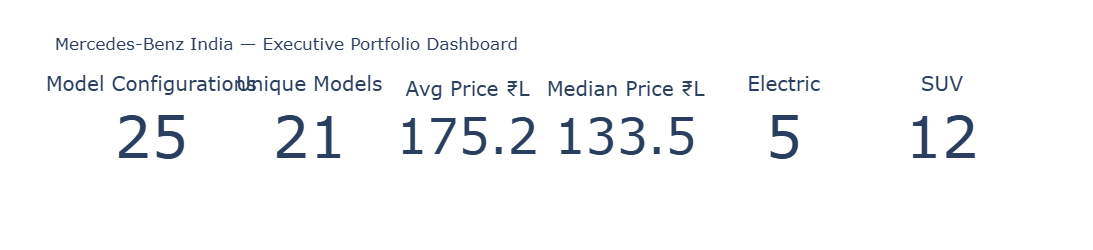

In [23]:
fig = go.Figure()

metrics = [
    ("Model Configurations", total_records),
    ("Unique Models", unique_models),
    ("Avg Price ₹L", round(avg_price, 1)),
    ("Median Price ₹L", round(median_price, 1)),
    ("Electric", electric_records),
    ("SUV", suv_records)
]

for i, (label, value) in enumerate(metrics):
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=value,
            title={"text": label},
            domain={
                "row": 1,
                "column": i
            }
        )
    )

fig.update_layout(
    grid={
        "rows": 1,
        "columns": 6
    },
    title="Mercedes-Benz India — Executive Portfolio Dashboard",
    height=250
)

fig.show()

### Portfolio Mix — Body Type

In [24]:
body_summary = (
    df.groupby("body_type")
      .agg(
          configurations=("model", "count"),
          unique_models=("model", "nunique"),
          avg_price=("starting_price_lakh", "mean"),
          min_price=("starting_price_lakh", "min"),
          max_price=("starting_price_lakh", "max")
      )
      .sort_values("configurations", ascending=False)
)

body_summary.round(2)

,configurations,unique_models,avg_price,min_price,max_price
body_type,,,,,
SUV,12,10,186.72,51.8,374.0
Limousine,8,7,134.47,56.5,287.5
Cabriolet / Roadster,2,2,272.50,115.0,430.0
Coupé,2,2,216.25,132.5,300.0
Hatchback,1,1,87.00,87.0,87.0


### Interactive Body Type Analysis

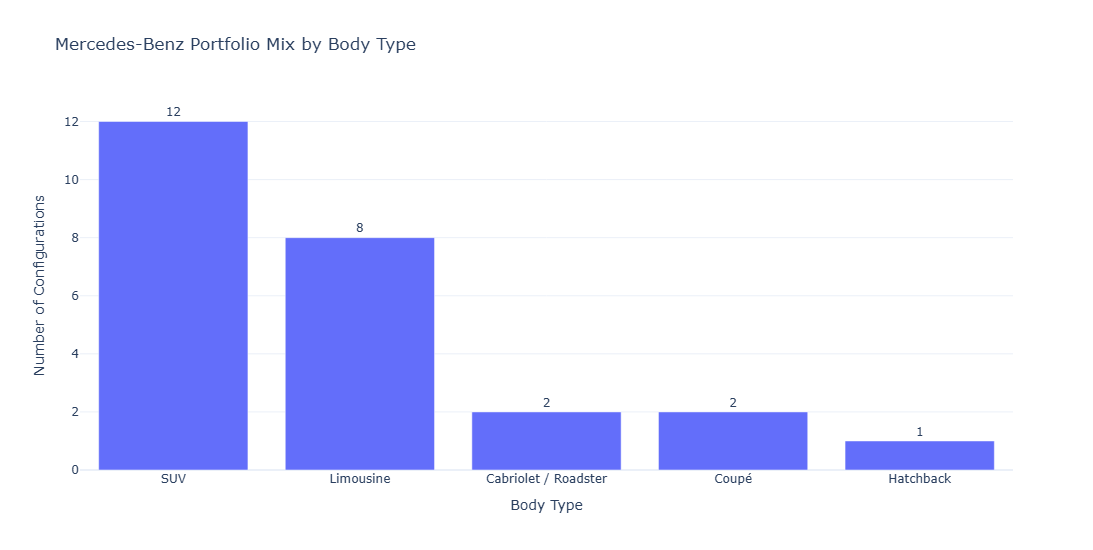

In [25]:
fig = px.bar(
    body_summary.reset_index(),
    x="body_type",
    y="configurations",
    text="configurations",
    title="Mercedes-Benz Portfolio Mix by Body Type",
    labels={
        "body_type": "Body Type",
        "configurations": "Number of Configurations"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    height=550
)

fig.show()

### Where is Mercedes-Benz concentrating its portfolio?

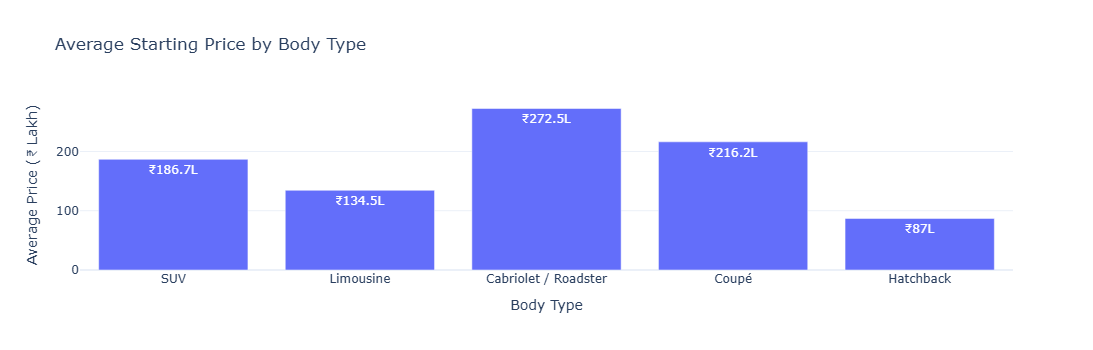

In [26]:
# Average Price by Body Type
fig = px.bar(
    body_summary.reset_index(),
    x="body_type",
    y="avg_price",
    text=body_summary["avg_price"].round(1),
    title="Average Starting Price by Body Type",
    labels={
        "body_type": "Body Type",
        "avg_price": "Average Price (₹ Lakh)"
    }
)

fig.update_traces(texttemplate="₹%{text}L")

fig.update_layout(
    template="plotly_white",
    height=350
)

fig.show()

#### Business insight : This helps identify which vehicle categories are positioned as volume-oriented vs high-value luxury categories.

### Price Ladder — Advanced Visualization

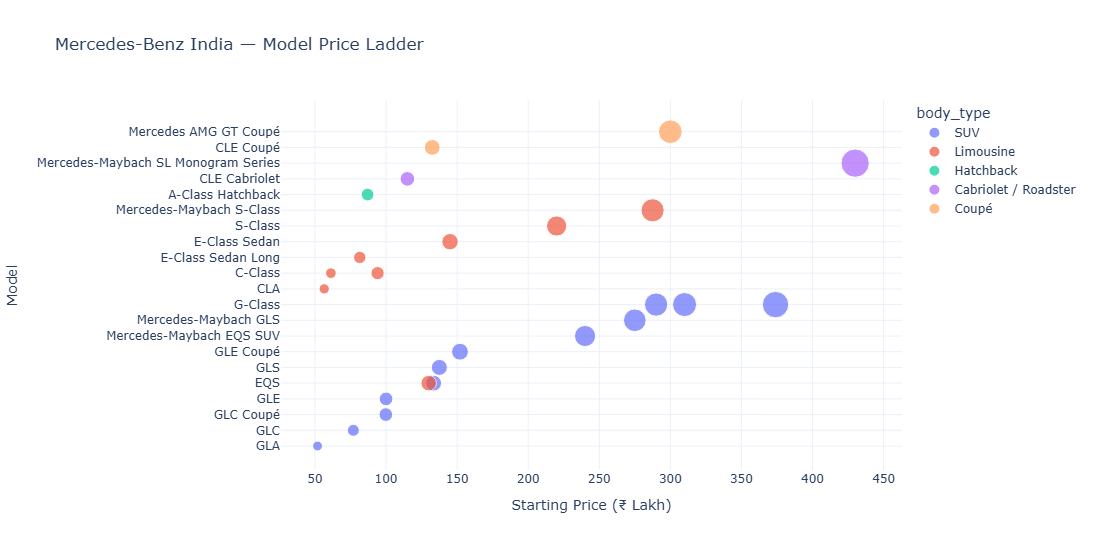

In [27]:
price_ladder = df.sort_values(
    "starting_price_lakh"
).reset_index(drop=True)

fig = px.scatter(
    price_ladder,
    x="starting_price_lakh",
    y="model",
    size="starting_price_lakh",
    color="body_type",
    hover_data=[
        "fuel_type",
        "price_segment",
        "price_cr"
    ],
    title="Mercedes-Benz India — Model Price Ladder",
    labels={
        "starting_price_lakh": "Starting Price (₹ Lakh)",
        "model": "Model"
    }
)

fig.update_layout(
    template="plotly_white",
    height=550
)

fig.show()

### Price Distribution

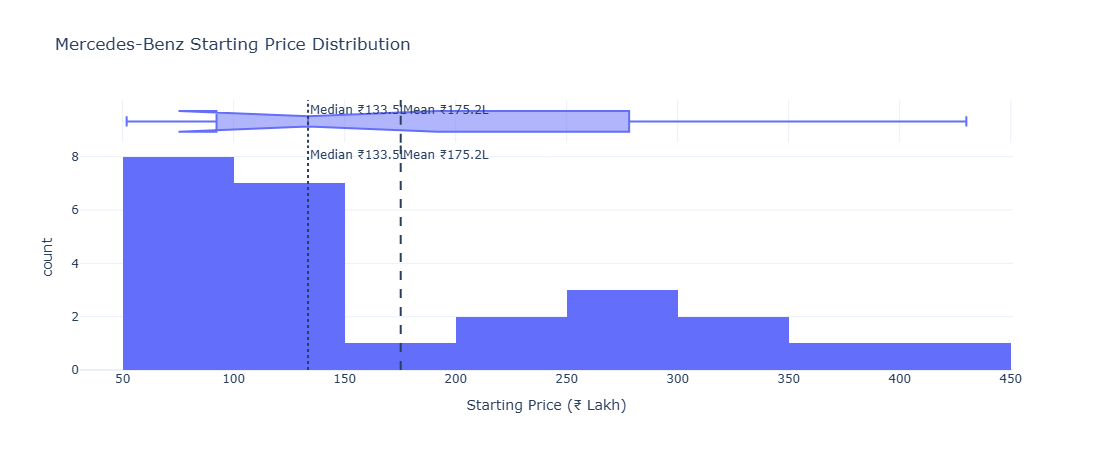

In [28]:
fig = px.histogram(
    df,
    x="starting_price_lakh",
    nbins=10,
    marginal="box",
    title="Mercedes-Benz Starting Price Distribution",
    labels={
        "starting_price_lakh": "Starting Price (₹ Lakh)"
    }
)

fig.add_vline(
    x=avg_price,
    line_dash="dash",
    annotation_text=f"Mean ₹{avg_price:.1f}L"
)

fig.add_vline(
    x=median_price,
    line_dash="dot",
    annotation_text=f"Median ₹{median_price:.1f}L"
)

fig.update_layout(
    template="plotly_white",
    height=450
)

fig.show()

In [29]:
# Price Segment Analysis
segment_order = [
    "Entry / Premium",
    "Luxury",
    "Ultra Luxury",
    "High Luxury"
]

segment_summary = (
    df["price_segment"]
    .value_counts()
    .reindex(segment_order)
    .fillna(0)
    .reset_index()
)

segment_summary.columns = [
    "price_segment",
    "models"
]

segment_summary

,price_segment,models
0,Entry / Premium,4
1,Luxury,11
2,Ultra Luxury,3
3,High Luxury,7


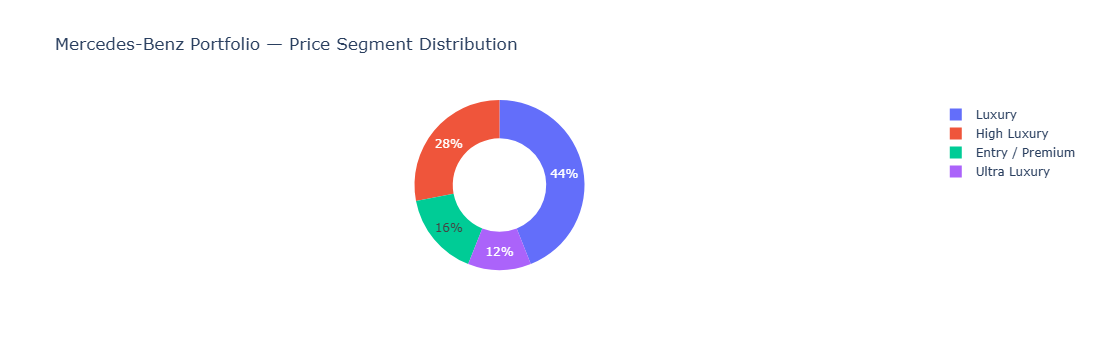

In [30]:
fig = px.pie(
    segment_summary,
    names="price_segment",
    values="models",
    hole=0.55,
    title="Mercedes-Benz Portfolio — Price Segment Distribution"
)

fig.update_layout(
    template="plotly_white",
    height=350
)

fig.show()

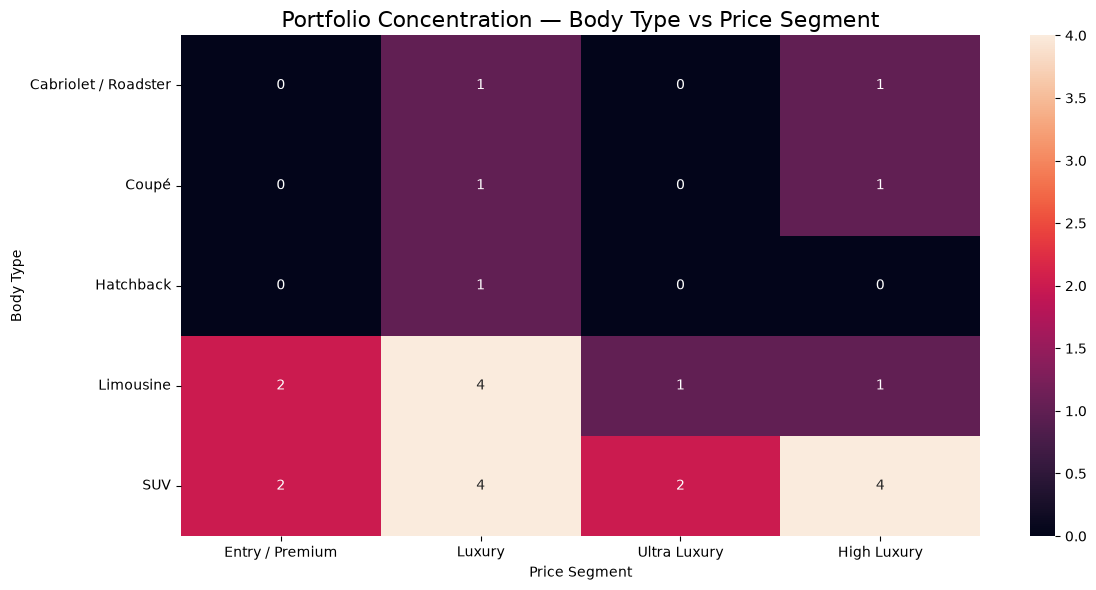

In [31]:
segment_body = pd.crosstab(
    df["body_type"],
    df["price_segment"]
)

segment_body = segment_body.reindex(
    columns=segment_order,
    fill_value=0
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    segment_body,
    annot=True,
    fmt="d"
)

plt.title(
    "Portfolio Concentration — Body Type vs Price Segment",
    fontsize=16
)

plt.xlabel("Price Segment")
plt.ylabel("Body Type")

plt.tight_layout()
plt.show()

In [32]:
# Powertrain Analysis
fuel_summary = (
    df.groupby("fuel_type")
      .agg(
          configurations=("model", "count"),
          unique_models=("model", "nunique"),
          avg_price=("starting_price_lakh", "mean"),
          min_price=("starting_price_lakh", "min"),
          max_price=("starting_price_lakh", "max")
      )
      .sort_values("configurations", ascending=False)
)

fuel_summary.round(2)

,configurations,unique_models,avg_price,min_price,max_price
fuel_type,,,,,
Petrol,10,10,225.28,87.00,430.00
Petrol / Diesel,6,6,84.83,51.80,137.50
Electric,5,4,174.00,56.50,310.00
Plug-in Hybrid,2,2,182.50,145.00,220.00
Diesel,1,1,290.00,290.00,290.00
Plug-in Hybrid Petrol,1,1,94.05,94.05,94.05


### Cheapest & Most Expensive Models

In [33]:
cheapest = df.loc[df["starting_price_lakh"].idxmin()]
expensive = df.loc[df["starting_price_lakh"].idxmax()]

print("Cheapest:", cheapest["model"], "₹", cheapest["starting_price_lakh"], "Lakh")
print("Most Expensive:", expensive["model"], "₹", expensive["starting_price_lakh"], "Lakh")

Cheapest: GLA ₹ 51.8 Lakh
Most Expensive: Mercedes-Maybach SL Monogram Series ₹ 430.0 Lakh


In [34]:
df.groupby("body_type")["starting_price_lakh"].mean().sort_values(ascending=False)

body_type
Cabriolet / Roadster    272.500000
Coupé                   216.250000
SUV                     186.720833
Limousine               134.468750
Hatchback                87.000000
Name: starting_price_lakh, dtype: float64

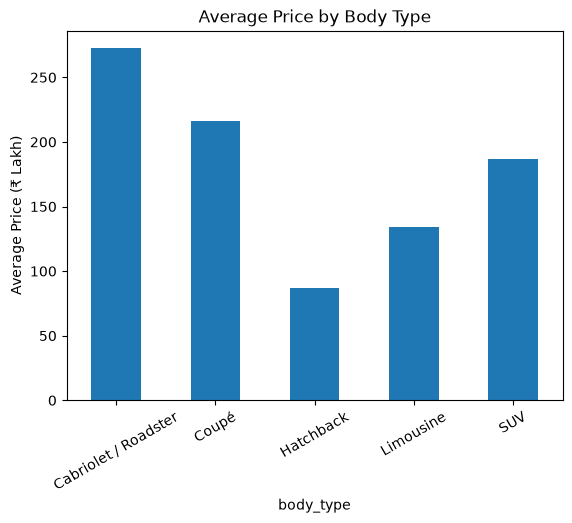

In [35]:
df.groupby("body_type")["starting_price_lakh"].mean().plot(
    kind="bar",
    title="Average Price by Body Type"
)

plt.ylabel("Average Price (₹ Lakh)")
plt.xticks(rotation=30)
plt.show()

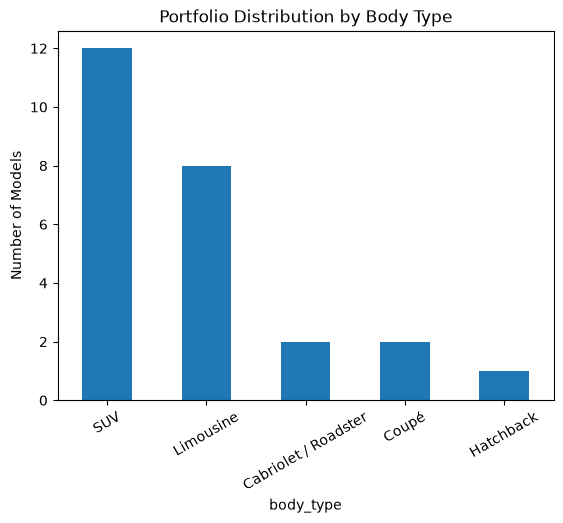

In [36]:
# Model Count by Body Type
body_count = df["body_type"].value_counts()

body_count.plot(
    kind="bar",
    title="Portfolio Distribution by Body Type"
)

plt.ylabel("Number of Models")
plt.xticks(rotation=30)
plt.show()

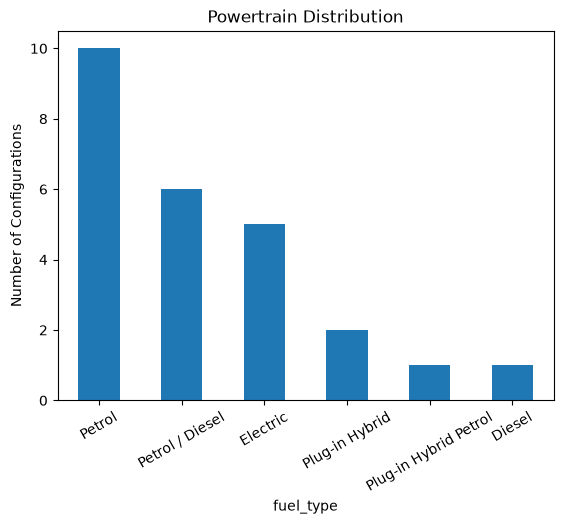

In [37]:
fuel_count = df["fuel_type"].value_counts()

fuel_count.plot(
    kind="bar",
    title="Powertrain Distribution"
)

plt.ylabel("Number of Configurations")
plt.xticks(rotation=30)
plt.show()

In [38]:
ev = df[
    df["fuel_type"].str.contains("electric", case=False, na=False)
]

ev[[
    "model",
    "body_type",
    "starting_price_lakh"
]].sort_values("starting_price_lakh")

,model,body_type,starting_price_lakh
0,CLA,Limousine,56.5
3,EQS,Limousine,130.0
8,EQS,SUV,133.5
9,Mercedes-Maybach EQS SUV,SUV,240.0
15,G-Class,SUV,310.0


#### Models Below ₹1 Crore

In [39]:
under_1cr = df[
    df["starting_price_lakh"] < 100
].sort_values("starting_price_lakh")

under_1cr[
    ["model", "body_type", "fuel_type", "starting_price_lakh"]
]

,model,body_type,fuel_type,starting_price_lakh
10,GLA,SUV,Petrol / Diesel,51.80
0,CLA,Limousine,Electric,56.50
1,C-Class,Limousine,Petrol / Diesel,61.20
11,GLC,SUV,Petrol / Diesel,77.00
4,E-Class Sedan Long,Limousine,Petrol / Diesel,81.50
22,A-Class Hatchback,Hatchback,Petrol,87.00
2,C-Class,Limousine,Plug-in Hybrid Petrol,94.05
18,GLC Coupé,SUV,Petrol,99.85


### Models Above ₹2 Crore

In [40]:
above_2cr = df[
    df["starting_price_lakh"] >= 200
].sort_values("starting_price_lakh", ascending=False)

above_2cr[
    ["model", "body_type", "fuel_type", "starting_price_lakh"]
]

,model,body_type,fuel_type,starting_price_lakh
21,Mercedes-Maybach SL Monogram Series,Cabriolet / Roadster,Petrol,430.0
17,G-Class,SUV,Petrol,374.0
15,G-Class,SUV,Electric,310.0
24,Mercedes AMG GT Coupé,Coupé,Petrol,300.0
16,G-Class,SUV,Diesel,290.0
6,Mercedes-Maybach S-Class,Limousine,Petrol,287.5
14,Mercedes-Maybach GLS,SUV,Petrol,275.0
9,Mercedes-Maybach EQS SUV,SUV,Electric,240.0
5,S-Class,Limousine,Plug-in Hybrid,220.0


In [41]:
# Price Segment Analysis
df["price_segment"] = pd.cut(
    df["starting_price_lakh"],
    bins=[0, 80, 150, 250, np.inf],
    labels=[
        "Entry Premium",
        "Luxury",
        "Ultra Luxury",
        "High Luxury"
    ]
)

df["price_segment"].value_counts().sort_index()

price_segment
Entry Premium     4
Luxury           11
Ultra Luxury      3
High Luxury       7
Name: count, dtype: int64

In [42]:
pd.crosstab(
    df["body_type"],
    df["price_segment"]
)

price_segment,Entry Premium,Luxury,Ultra Luxury,High Luxury
body_type,,,,
Cabriolet / Roadster,0,1,0,1
Coupé,0,1,0,1
Hatchback,0,1,0,0
Limousine,2,4,1,1
SUV,2,4,2,4


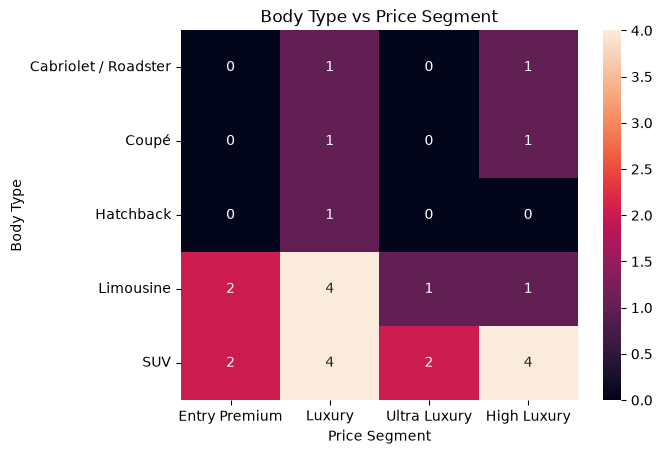

In [43]:
segment_matrix = pd.crosstab(
    df["body_type"],
    df["price_segment"]
)

sns.heatmap(
    segment_matrix,
    annot=True,
    fmt="d"
)

plt.title("Body Type vs Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Body Type")
plt.show()

In [44]:
print("BUSINESS SUMMARY")
print("-" * 50)
print(f"Total configurations: {len(df)}")
print(
    f"Largest body type: "
    f"{df['body_type'].value_counts().idxmax()}"
)
print(
    f"Average starting price: "
    f"₹{df['starting_price_lakh'].mean():.1f} Lakh"
)
print(
    f"Cheapest model: "
    f"{df.loc[df['starting_price_lakh'].idxmin(), 'model']}"
)
print(
    f"Most expensive model: "
    f"{df.loc[df['starting_price_lakh'].idxmax(), 'model']}"
)
print(
    f"Electric configurations: "
    f"{df['fuel_type'].str.contains('electric', case=False, na=False).sum()}"
)

BUSINESS SUMMARY
--------------------------------------------------
Total configurations: 25
Largest body type: SUV
Average starting price: ₹175.2 Lakh
Cheapest model: GLA
Most expensive model: Mercedes-Maybach SL Monogram Series
Electric configurations: 5
